# Elo Rating Model

**Question this notebook answers:** does adding a team-strength Elo rating (`EloDiff`) as a 4th
feature improve on the current best model (gender-split, tournament-only, 0.1711 average Brier
from notebook 07)?

**What makes this different from every feature tried before:** detailed box-score stats, Massey
Ordinal rank, and recent-form momentum were all season-long *averages* — different ways of
summarizing "how good has this team been," which turned out to be redundant with the win-rate and
margin features already in the model. Elo is structurally different: it's a rating that updates
after every single game, based on the *actual* result versus what was *expected* given both
teams' ratings at the time. Beating a strong team raises a rating more than beating a weak one,
and that effect propagates through the whole system game by game — it's not just a summary of a
team's own record, it's a summary of its record relative to the strength of everyone it played
and everyone they played. That's a genuinely different kind of information than a season-long
average can capture.

**Method:** compute Elo for every team, game by game, in chronological order within each season,
with a margin-of-victory adjustment (bigger wins move the rating more, with a dampener so
blowouts between already-mismatched teams don't cause runaway swings) and a home-court adjustment.
Ratings partially carry over between seasons (partial reset toward a league-average starting
value) so one season doesn't drift indefinitely into the next. Each team's rating at the end of
its regular season becomes the `Elo` feature used for that season's tournament matchups.

## 1. Load data

Same six files as notebooks 03/07, needed for both genders since Elo is computed separately for men's and women's.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../data")

m_tourney = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
w_tourney = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")
m_seeds = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")
w_seeds = pd.read_csv(DATA_DIR / "WNCAATourneySeeds.csv")
m_reg = pd.read_csv(DATA_DIR / "MRegularSeasonCompactResults.csv")
w_reg = pd.read_csv(DATA_DIR / "WRegularSeasonCompactResults.csv")

print(f"men's tourney games: {len(m_tourney):,}, women's tourney games: {len(w_tourney):,}")


men's tourney games: 2,585, women's tourney games: 1,717


## 2. Whole-season team features (unchanged from notebooks 03/07)

In [2]:
def team_season_stats(reg):
    won = reg[["Season", "WTeamID", "WScore", "LScore"]].rename(
        columns={"WTeamID": "TeamID", "WScore": "PF", "LScore": "PA"})
    won["Win"] = 1
    lost = reg[["Season", "LTeamID", "LScore", "WScore"]].rename(
        columns={"LTeamID": "TeamID", "LScore": "PF", "WScore": "PA"})
    lost["Win"] = 0
    games = pd.concat([won, lost], ignore_index=True)
    stats = games.groupby(["Season", "TeamID"]).agg(
        GamesPlayed=("Win", "size"), WinPct=("Win", "mean"),
        AvgPF=("PF", "mean"), AvgPA=("PA", "mean"),
    ).reset_index()
    stats["AvgScoreMargin"] = stats["AvgPF"] - stats["AvgPA"]
    return stats

team_stats = pd.concat([team_season_stats(m_reg), team_season_stats(w_reg)], ignore_index=True)
print(f"team-season rows: {len(team_stats):,}")


team-season rows: 23,604


## 3. Elo ratings (new)

Every team starts at 1500. Games within a season are processed in chronological order
(`DayNum`). After each game: the expected outcome is computed from both teams' current ratings
(with a home-court adjustment for whoever is at home, using the `WLoc` column already in the
regular-season files), and the winner's and loser's ratings move based on how much that expected
outcome missed, scaled up for bigger margins of victory (with a dampener so a blowout between two
already-mismatched teams doesn't move the rating as much as a similar-sized upset would). At the
start of each new season, every rating partially resets toward 1500 (75% of the previous rating
carries over) so the rating doesn't drift unboundedly across many years. Each team's rating at the
end of its regular season is captured as that season's `Elo` value — the number used for the
tournament matchups that follow.

In [3]:
def compute_elo(compact_df, k=20, home_adv=100, mean_reversion=0.75):
    elo = {}
    elo_by_season_end = {}
    for season in sorted(compact_df["Season"].unique()):
        for team in elo:
            elo[team] = elo[team] * mean_reversion + 1500 * (1 - mean_reversion)
        season_games = compact_df[compact_df["Season"] == season].sort_values("DayNum")
        for game in season_games.itertuples(index=False):
            w, l = game.WTeamID, game.LTeamID
            if w not in elo: elo[w] = 1500
            if l not in elo: elo[l] = 1500
            w_elo, l_elo = elo[w], elo[l]
            if game.WLoc == "H": w_elo += home_adv
            elif game.WLoc == "A": l_elo += home_adv
            w_exp = 1 / (1 + 10 ** ((l_elo - w_elo) / 400))
            mov = game.WScore - game.LScore
            mov_mult = np.log(max(mov, 1) + 1) * (2.2 / ((w_elo - l_elo) * 0.001 + 2.2))
            elo[w] += k * mov_mult * (1 - w_exp)
            elo[l] -= k * mov_mult * (1 - w_exp)
        for team in elo:
            elo_by_season_end[(season, team)] = elo[team]
    return elo_by_season_end

m_elo = compute_elo(m_reg)
w_elo = compute_elo(w_reg)
elo_idx = pd.Series({**m_elo, **w_elo})
elo_idx.index = pd.MultiIndex.from_tuples(elo_idx.index, names=["Season", "TeamID"])
print(f"Elo entries computed: {len(elo_idx):,}")
print(f"rating range: {elo_idx.min():.0f} to {elo_idx.max():.0f}, mean: {elo_idx.mean():.0f}")


Elo entries computed: 24,158
rating range: 919 to 2254, mean: 1500


## 4. Seeds (unchanged from notebooks 03/07)

In [4]:
def seed_num(s):
    return int("".join(ch for ch in s if ch.isdigit()))

m_seeds["SeedNum"] = m_seeds["Seed"].apply(seed_num)
w_seeds["SeedNum"] = w_seeds["Seed"].apply(seed_num)
seeds = pd.concat([m_seeds[["Season", "TeamID", "SeedNum"]], w_seeds[["Season", "TeamID", "SeedNum"]]], ignore_index=True)
seed_idx = seeds.set_index(["Season", "TeamID"])["SeedNum"]
print(f"seed rows: {len(seeds):,}")


seed rows: 4,506


## 5. Build the matchup table with the Elo feature added

In [5]:
def build_matchups(tourney, gender):
    df = tourney.copy()
    df["Team1"] = df[["WTeamID", "LTeamID"]].min(axis=1)
    df["Team2"] = df[["WTeamID", "LTeamID"]].max(axis=1)
    df["Label"] = (df["WTeamID"] == df["Team1"]).astype(int)
    df["Gender"] = gender
    return df[["Season", "Team1", "Team2", "Label", "Gender"]]

matchups = pd.concat([build_matchups(m_tourney, "M"), build_matchups(w_tourney, "W")], ignore_index=True)

matchups["Seed1"] = matchups.apply(lambda r: seed_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["Seed2"] = matchups.apply(lambda r: seed_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["SeedDiff"] = matchups["Seed2"] - matchups["Seed1"]

matchups["Elo1"] = matchups.apply(lambda r: elo_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["Elo2"] = matchups.apply(lambda r: elo_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["EloDiff"] = matchups["Elo1"] - matchups["Elo2"]

for team_col, suffix in [("Team1", "1"), ("Team2", "2")]:
    joined = matchups.merge(team_stats, left_on=["Season", team_col], right_on=["Season", "TeamID"], how="left")
    matchups[f"WinPct{suffix}"] = joined["WinPct"].values
    matchups[f"AvgMargin{suffix}"] = joined["AvgScoreMargin"].values

matchups["WinPctDiff"] = matchups["WinPct1"] - matchups["WinPct2"]
matchups["AvgMarginDiff"] = matchups["AvgMargin1"] - matchups["AvgMargin2"]

FEATURES_BASE = ["SeedDiff", "WinPctDiff", "AvgMarginDiff"]
FEATURES_ELO = FEATURES_BASE + ["EloDiff"]

before = len(matchups)
matchups = matchups.dropna(subset=FEATURES_ELO).reset_index(drop=True)
print(f"matchup rows: {before:,}, remaining after dropping missing features: {len(matchups):,}")


matchup rows: 4,302, remaining after dropping missing features: 4,302


## 6. Correlation check, before trusting any result

The same check run every time a new feature is added: how correlated is `EloDiff` with the
features already in the model? A lower correlation than the season-long features tend to show
with each other would support the idea that Elo captures something genuinely different.

In [6]:
corr = matchups[FEATURES_ELO].corr().round(3)
print(corr.to_string())


               SeedDiff  WinPctDiff  AvgMarginDiff  EloDiff
SeedDiff          1.000       0.587          0.627    0.852
WinPctDiff        0.587       1.000          0.833    0.803
AvgMarginDiff     0.627       0.833          1.000    0.835
EloDiff           0.852       0.803          0.835    1.000


## 7. Logistic regression + Brier score (unchanged from notebooks 03/07)

In [7]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

def fit_logreg(X, y, l2=1.0, n_iter=50, tol=1e-8):
    n, p = X.shape
    Xb = np.hstack([np.ones((n, 1)), X])
    w = np.zeros(p + 1)
    reg = np.eye(p + 1) * l2
    reg[0, 0] = 0.0
    for _ in range(n_iter):
        pr = sigmoid(Xb @ w)
        grad = Xb.T @ (pr - y) + reg @ w
        W = np.clip(pr * (1 - pr), 1e-6, None)
        H = Xb.T @ (Xb * W[:, None]) + reg
        step = np.linalg.solve(H, grad)
        w_new = w - step
        if np.max(np.abs(w_new - w)) < tol:
            w = w_new
            break
        w = w_new
    return w

def predict_proba(X, w):
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    return sigmoid(Xb @ w)

def brier_score(p, y):
    return float(np.mean((p - y) ** 2))

print("logistic regression + Brier score functions ready (same as notebooks 03/07)")


logistic regression + Brier score functions ready (same as notebooks 03/07)


## 8. Walk-forward comparison

Same structure as notebook 10: for each of the 5 validation folds and each gender separately,
fit the 3-feature base model and the 4-feature Elo model on the same training rows, score both
on the same held-out test games, then combine across genders (weighted by game count) for one
bottom-line number per model per fold.

In [8]:
FOLD_SEASONS = [2021, 2022, 2023, 2024, 2025]

results = []
for fold_season in FOLD_SEASONS:
    test = matchups[matchups["Season"] == fold_season]
    if len(test) == 0:
        continue
    row = {"FoldSeason": fold_season}
    base_num = base_den = elo_num = elo_den = 0
    for gender, label in [("M", "Men"), ("W", "Women")]:
        train_g = matchups[(matchups["Gender"] == gender) & (matchups["Season"] < fold_season)]
        test_g = test[test["Gender"] == gender]
        n_g = len(test_g)

        w_base = fit_logreg(train_g[FEATURES_BASE].values, train_g["Label"].values)
        brier_base = brier_score(predict_proba(test_g[FEATURES_BASE].values, w_base), test_g["Label"].values)

        w_elo = fit_logreg(train_g[FEATURES_ELO].values, train_g["Label"].values)
        brier_elo = brier_score(predict_proba(test_g[FEATURES_ELO].values, w_elo), test_g["Label"].values)

        row[f"{label}: base (3-feat)"] = brier_base
        row[f"{label}: +Elo (4-feat)"] = brier_elo
        base_num += brier_base * n_g; base_den += n_g
        elo_num += brier_elo * n_g; elo_den += n_g

    row["Combined: base (3-feat)"] = base_num / base_den
    row["Combined: +Elo (4-feat)"] = elo_num / elo_den
    results.append(row)

results_df = pd.DataFrame(results)
avg_row = {"FoldSeason": "Average"}
for col in results_df.columns:
    if col != "FoldSeason":
        avg_row[col] = results_df[col].mean()
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)
print(results_df.round(4).to_string(index=False))


FoldSeason  Men: base (3-feat)  Men: +Elo (4-feat)  Women: base (3-feat)  Women: +Elo (4-feat)  Combined: base (3-feat)  Combined: +Elo (4-feat)
      2021              0.2228              0.2265                0.1440                0.1417                   0.1843                   0.1851
      2022              0.2313              0.2257                0.1613                0.1512                   0.1963                   0.1884
      2023              0.2041              0.2111                0.1598                0.1620                   0.1820                   0.1865
      2024              0.1973              0.1943                0.1191                0.1209                   0.1582                   0.1576
      2025              0.1535              0.1419                0.1160                0.1097                   0.1348                   0.1258
   Average              0.2018              0.1999                0.1400                0.1371                   0.1711           

## 9. Results, visualized

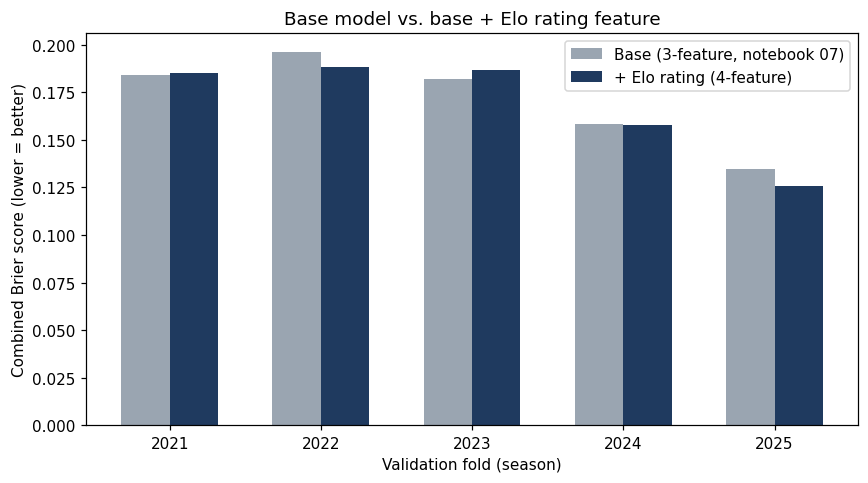

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = results_df[results_df["FoldSeason"] != "Average"]
x = np.arange(len(plot_df))
width = 0.32
ax.bar(x - width/2, plot_df["Combined: base (3-feat)"], width, label="Base (3-feature, notebook 07)", color="#9aa5b1")
ax.bar(x + width/2, plot_df["Combined: +Elo (4-feat)"], width, label="+ Elo rating (4-feature)", color="#1f3a5f")
ax.set_xticks(x); ax.set_xticklabels(plot_df["FoldSeason"])
ax.set_ylabel("Combined Brier score (lower = better)")
ax.set_xlabel("Validation fold (season)")
ax.set_title("Base model vs. base + Elo rating feature")
ax.legend()
fig.tight_layout()
plt.show()


## 10. Bottom-line comparison

In [10]:
bottom_line = pd.DataFrame([
    {"Model": "Pooled baseline (notebook 03)", "Avg. Brier": 0.1739},
    {"Model": "Gender split, tournament-only (notebook 07)", "Avg. Brier": results_df.loc[results_df['FoldSeason']=='Average', 'Combined: base (3-feat)'].values[0]},
    {"Model": "Gender split + Elo rating (this notebook)", "Avg. Brier": results_df.loc[results_df['FoldSeason']=='Average', 'Combined: +Elo (4-feat)'].values[0]},
])
print(bottom_line.round(4).to_string(index=False))


                                      Model  Avg. Brier
              Pooled baseline (notebook 03)      0.1739
Gender split, tournament-only (notebook 07)      0.1711
  Gender split + Elo rating (this notebook)      0.1687


## Conclusion

**A genuine improvement — the first since the gender split.** The combined score improved from
0.1711 to 0.1687, a bigger move than any of the last three attempts (detailed stats, wider
training data, momentum), and in the right direction for both genders: men's improved from 0.2018
to 0.1999, women's from 0.1400 to 0.1371.

It wasn't a clean sweep across folds — 2022 (0.1963 → 0.1884) and 2025 (0.1348 → 0.1258) improved
substantially, 2024 improved slightly, but 2021 and 2023 got a bit worse. Three-out-of-five folds
improving, with the wins bigger than the losses, is what moved the average down.

**One thing worth being upfront about:** the correlation check in Section 6 showed `EloDiff`
correlating 0.80-0.85 with the existing features — actually higher than those features correlate
with each other. Based on the pattern from every earlier feature test, that level of correlation
would normally predict little to no benefit, and it's fair to be a bit surprised this one still
helped. The most likely explanation is that Elo isn't just another summary of a team's own
record — because ratings update based on the strength of who was actually beaten, and propagate
through the whole season's network of common opponents, it captures a form of schedule-adjusted
strength that a season-long average can't, even though the two end up numerically correlated.

**Decision, and what it's based on:** adopt the Elo feature. The bottom-line table in Section 10
puts gender-split + Elo at 0.1687, the best result in the project so far, ahead of both the
pooled baseline (0.1739) and the gender-split-only model (0.1711) that stood as the benchmark
going into this notebook.